In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15 
from functools import partial 

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 

import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline    
from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid
from jax.random import PRNGKey, key    
from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint
from diffrax import backward_hermite_coefficients, CubicInterpolation    
from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, NamedSharding



/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
/tmp/ipykernel_892647/3748235943.py:21: DeprecationWarning: jax.experimental.shard_map is deprecated in v0.8.0. Used jax.shard_map instead.
  from jax.experimental.shard_map import shard_map


In [114]:
### from sapphire/models/pandya23.py

zarr = jnp.linspace(10.0,0.0,100)
tarr = jnp.asarray(Planck15.age(zarr).value) # Gyr
interp_rhocrit_z = jit(InterpolatedUnivariateSpline(jnp.asarray(zarr),jnp.asarray(Planck15.critical_density(zarr).value),k=3))
interp_Om_z = jit(InterpolatedUnivariateSpline(jnp.asarray(zarr),jnp.asarray(Planck15.Om(zarr)),k=3))
interp_redshift = jit(InterpolatedUnivariateSpline(jnp.asarray(tarr),jnp.asarray(zarr),k=3))

In [120]:
### test switching to interpax instead
from interpax import Interpolator1D, interp1d

rhocrit_arr = jnp.asarray(Planck15.critical_density(zarr).value)
Om_arr = jnp.asarray(Planck15.Om(zarr))
                          

interpax_rhocrit_z = jit(Interpolator1D(zarr[::-1],rhocrit_arr[::-1], method="cubic2",
                                       extrap=(rhocrit_arr[-1], rhocrit_arr[0])).__call__)

interpax_Om_z = jit(Interpolator1D(zarr[::-1],Om_arr[::-1], method="cubic2",
                                   extrap=(Om_arr[-1], Om_arr[0])).__call__)

interpax_redshift = jit(Interpolator1D(tarr,jnp.asarray(zarr), method="cubic2",
                                         extrap=(zarr[0], zarr[-1])).__call__)

In [126]:
interpax_rhocrit_z(zarr), interp_rhocrit_z(zarr)

(Array([3.55987826e-27, 3.46277958e-27, 3.36746746e-27, 3.27392526e-27,
        3.18213631e-27, 3.09208397e-27, 3.00375160e-27, 2.91712255e-27,
        2.83218018e-27, 2.74890785e-27, 2.66728892e-27, 2.58730676e-27,
        2.50894472e-27, 2.43218617e-27, 2.35701449e-27, 2.28341304e-27,
        2.21136519e-27, 2.14085432e-27, 2.07186380e-27, 2.00437701e-27,
        1.93837734e-27, 1.87384815e-27, 1.81077283e-27, 1.74913477e-27,
        1.68891735e-27, 1.63010396e-27, 1.57267798e-27, 1.51662282e-27,
        1.46192186e-27, 1.40855850e-27, 1.35651613e-27, 1.30577815e-27,
        1.25632797e-27, 1.20814898e-27, 1.16122459e-27, 1.11553820e-27,
        1.07107322e-27, 1.02781305e-27, 9.85741122e-28, 9.44840830e-28,
        9.05095594e-28, 8.66488829e-28, 8.29003952e-28, 7.92624383e-28,
        7.57333543e-28, 7.23114855e-28, 6.89951743e-28, 6.57827634e-28,
        6.26725955e-28, 5.96630136e-28, 5.67523610e-28, 5.39389809e-28,
        5.12212168e-28, 4.85974124e-28, 4.60659115e-28, 4.362505

In [113]:
interp1d(zarr[::-1], zarr[::-1], rhocrit_arr[::-1], method="cubic")

Array([8.61916045e-30, 9.51055748e-30, 1.05815170e-29, 1.18485228e-29,
       1.33280603e-29, 1.50366168e-29, 1.69906810e-29, 1.92067436e-29,
       2.17012969e-29, 2.44908349e-29, 2.75918534e-29, 3.10208498e-29,
       3.47943232e-29, 3.89287747e-29, 4.34407067e-29, 4.83466236e-29,
       5.36630315e-29, 5.94064380e-29, 6.55933528e-29, 7.22402870e-29,
       7.93637535e-29, 8.69802670e-29, 9.51063438e-29, 1.03758502e-28,
       1.12953262e-28, 1.22707144e-28, 1.33036673e-28, 1.43958373e-28,
       1.55488770e-28, 1.67644394e-28, 1.80441775e-28, 1.93897444e-28,
       2.08027935e-28, 2.22849784e-28, 2.38379528e-28, 2.54633705e-28,
       2.71628856e-28, 2.89381524e-28, 3.07908253e-28, 3.27225587e-28,
       3.47350076e-28, 3.68298268e-28, 3.90086714e-28, 4.12731968e-28,
       4.36250583e-28, 4.60659115e-28, 4.85974124e-28, 5.12212168e-28,
       5.39389809e-28, 5.67523610e-28, 5.96630136e-28, 6.26725955e-28,
       6.57827634e-28, 6.89951743e-28, 7.23114855e-28, 7.57333543e-28,
      

In [112]:
zarr

Array([10.        ,  9.8989899 ,  9.7979798 ,  9.6969697 ,  9.5959596 ,
        9.49494949,  9.39393939,  9.29292929,  9.19191919,  9.09090909,
        8.98989899,  8.88888889,  8.78787879,  8.68686869,  8.58585859,
        8.48484848,  8.38383838,  8.28282828,  8.18181818,  8.08080808,
        7.97979798,  7.87878788,  7.77777778,  7.67676768,  7.57575758,
        7.47474747,  7.37373737,  7.27272727,  7.17171717,  7.07070707,
        6.96969697,  6.86868687,  6.76767677,  6.66666667,  6.56565657,
        6.46464646,  6.36363636,  6.26262626,  6.16161616,  6.06060606,
        5.95959596,  5.85858586,  5.75757576,  5.65656566,  5.55555556,
        5.45454545,  5.35353535,  5.25252525,  5.15151515,  5.05050505,
        4.94949495,  4.84848485,  4.74747475,  4.64646465,  4.54545455,
        4.44444444,  4.34343434,  4.24242424,  4.14141414,  4.04040404,
        3.93939394,  3.83838384,  3.73737374,  3.63636364,  3.53535354,
        3.43434343,  3.33333333,  3.23232323,  3.13131313,  3.03

In [109]:
rhocrit_arr

Array([3.55987826e-27, 3.46277958e-27, 3.36746746e-27, 3.27392526e-27,
       3.18213631e-27, 3.09208397e-27, 3.00375160e-27, 2.91712255e-27,
       2.83218018e-27, 2.74890785e-27, 2.66728892e-27, 2.58730676e-27,
       2.50894472e-27, 2.43218617e-27, 2.35701449e-27, 2.28341304e-27,
       2.21136519e-27, 2.14085432e-27, 2.07186380e-27, 2.00437701e-27,
       1.93837734e-27, 1.87384815e-27, 1.81077283e-27, 1.74913477e-27,
       1.68891735e-27, 1.63010396e-27, 1.57267798e-27, 1.51662282e-27,
       1.46192186e-27, 1.40855850e-27, 1.35651613e-27, 1.30577815e-27,
       1.25632797e-27, 1.20814898e-27, 1.16122459e-27, 1.11553820e-27,
       1.07107322e-27, 1.02781305e-27, 9.85741122e-28, 9.44840830e-28,
       9.05095594e-28, 8.66488829e-28, 8.29003952e-28, 7.92624383e-28,
       7.57333543e-28, 7.23114855e-28, 6.89951743e-28, 6.57827634e-28,
       6.26725955e-28, 5.96630136e-28, 5.67523610e-28, 5.39389809e-28,
       5.12212168e-28, 4.85974124e-28, 4.60659115e-28, 4.36250583e-28,
      

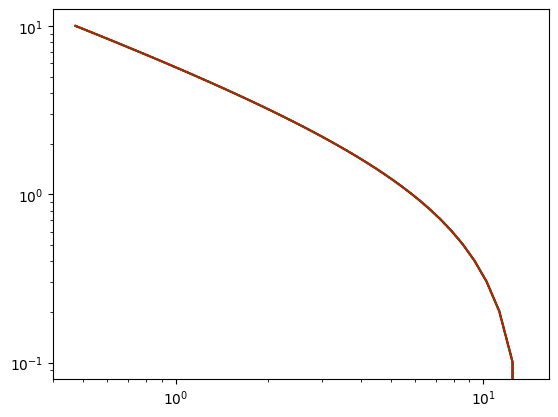

In [128]:
plt.loglog(tarr,zarr,'k-')
plt.loglog(tarr,interp_redshift(tarr),'r-')
plt.loglog(tarr,interpax_redshift(tarr),'g:')

In [ ]:
plt.loglog(zarr,Om_arr,'k-')
plt.loglog(zarr,interp_Om_z(zarr),'r-')
plt.loglog(zarr,interpax_Om_z(zarr),'g:')

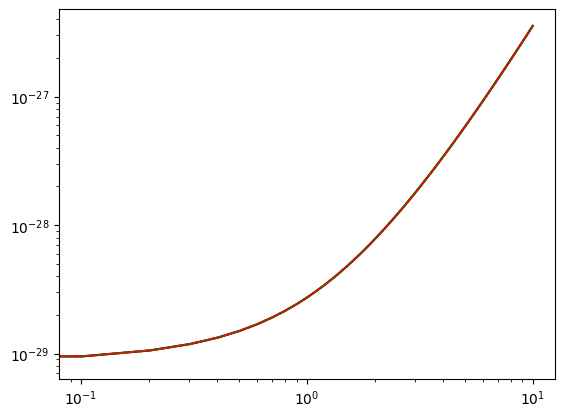

In [124]:
plt.loglog(zarr,rhocrit_arr,'k-')
plt.loglog(zarr,interp_rhocrit_z(zarr),'r-')
plt.loglog(zarr,interpax_rhocrit_z(zarr),'g:')

In [68]:
interp_rhocrit_z(tarr[2]), interpax_rhocrit_z(tarr[2])

(Array(1.46933463e-29, dtype=float64), Array(8.61916045e-30, dtype=float64))

In [61]:
interpax_rhocrit_z(tarr[2])

Array(8.61916045e-30, dtype=float64)

In [35]:
interpax_redshift_z(0.0)

Array(10., dtype=float64)

In [40]:
jit(interpax_redshift.__call__)(0.0)

Array(10., dtype=float64)

In [64]:
%timeit interp_rhocrit_z(0.0)

9.53 μs ± 18.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [65]:
%timeit interpax_rhocrit_z(0.0)

10.1 μs ± 28.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [106]:
%timeit jnpint = jnp.interp(zarr,zarr,rhocrit_arr)

72.8 μs ± 224 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [105]:
%timeit fq = interp1d(zarr, zarr, rhocrit_arr, method="cubic")

13.2 μs ± 62.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
